In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from recognizer import recognizeOnAll
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, LSTM, Conv2D, Dropout, Bidirectional

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# resample signal to n samples
from scipy.signal import resample

# XML parser
import xml.etree.ElementTree as ET

# encoding and normalizing data
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [15]:
NUM_POINTS = 50

## Read Data

In [ ]:
data = []
myData = []
myDataRaw = []
checks = []

for root, subdirs, files in os.walk('xml_logs'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
  
                data.append((label, resampled))

print("Loading my Data")
for root, subdirs, files in os.walk('my_logs'):   
    if 'ipynb_checkpoint' in root:
        continue
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])

                myDataRaw.append((label, points)) 
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                myData.append((label, resampled))

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

Loading my Data


  0%|          | 0/160 [00:00<?, ?it/s]

In [17]:
print(myData[12])

('caret', array([[-1.39513321,  1.8640103 ],
       [-1.72141092,  1.77863598],
       [-1.57885359,  1.61124294],
       [-1.58704783,  1.45777949],
       [-1.50274297,  1.32130571],
       [-1.44714065,  1.17097992],
       [-1.38489672,  1.04405003],
       [-1.29451254,  0.91033464],
       [-1.22935168,  0.78652063],
       [-1.11929674,  0.65080584],
       [-1.07875358,  0.52857173],
       [-0.93878389,  0.39146218],
       [-0.89548636,  0.27059149],
       [-0.76494753,  0.13209161],
       [-0.72890243,  0.03380449],
       [-0.60751953, -0.11127163],
       [-0.55932418, -0.24944004],
       [-0.44653244, -0.38370843],
       [-0.41404094, -0.50556502],
       [-0.30108517, -0.64673099],
       [-0.29160254, -0.78895613],
       [-0.16731262, -0.91993842],
       [-0.14417586, -1.06213734],
       [-0.01954504, -1.20348246],
       [ 0.00246614, -1.3246104 ],
       [ 0.12839155, -1.45967073],
       [ 0.14904028, -1.59864575],
       [ 0.29051875, -1.70360955],
       [ 0

In [ ]:
#test_data = random.sample(data, 1)[0]

#label = test_data[0]
#sequence = test_data[1]

#print(label)
#plt.plot(sequence.T[0], sequence.T[1]*-1)

def showAllPlots():
    for mData in myData:
        my_test_data = mData
    
        my_label = my_test_data[0]
        my_sequence = my_test_data[1]
        plt.figure() 
        plt.title(f"Plot für {my_label}") 
        plt.plot(my_sequence.T[0], my_sequence.T[1] * -1)
        plt.show()
        
#showAllPlots() if one wants to see all gestures displayed

## Prepare Data

In [8]:
# Prepare the data
labels = [sample[0] for sample in data]
myLabels = [sample[0] for sample in myData]
print("labels: ", set(labels))

# encode (make string-labels numerical)
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)
myEncoder = LabelEncoder()
my_labels_encoded = myEncoder.fit_transform(myLabels)
print("encoded: ", set(labels_encoded))

# get labels of data
y = to_categorical(labels_encoded)
myY = to_categorical(my_labels_encoded)
print("num labels (encoded): ", len(y[0]))

# get point sequences of data
sequences = [sample[1] for sample in data]
mySequences = [sample[1] for sample in myData]
X = np.array(sequences)
myX = np.array(mySequences)

my_X_test = myX
my_y_test = myY
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

labels:  {'question_mark', 'arrow', 'right_curly_brace', 'pigtail', 'x', 'left_sq_bracket', 'triangle', 'star', 'left_curly_brace', 'delete_mark', 'v', 'caret', 'check', 'circle', 'right_sq_bracket', 'rectangle'}
encoded:  {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)}
num labels (encoded):  16
(4224, 50, 2) (1056, 50, 2) (4224, 16) (1056, 16)


## Define and Train Model 

In [ ]:
num_classes = len(set(labels))

#Model1
model1 = Sequential(name="Model-Big")
model1.add(Input((NUM_POINTS, 2)))

model1.add(Bidirectional(LSTM(64, return_sequences=True)))
model1.add(Dropout(0.2))
model1.add(Bidirectional(LSTM(32)))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(num_classes, activation='softmax'))

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#Model2
model2 = Sequential(name="Model-Medium")
model2.add(Input((NUM_POINTS, 2)))

model2.add(LSTM(32))
model2.add(Dropout(0.2))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(num_classes, activation='softmax'))

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#Model3
model3 = Sequential(name="Model-Small")
model3.add(Input((NUM_POINTS, 2)))

model3.add(LSTM(16))
model3.add(Dense(num_classes, activation='softmax'))

model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#Model4 (Original)
model4 = Sequential(name="Model-Original")
model4.add(Input((NUM_POINTS, 2)))
model4.add(LSTM(64))
model4.add(Dense(32, activation='relu'))

model4.add(Dense(len(set(labels)), activation='softmax'))

model4.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


models = [model1, model2, model3, model4]

In [10]:
import time
histories = []
fittingTimes = []

for model in models:
    
    print(f"\n---------------Training {model.name}--------------------")
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
    stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    startTime = int(time.time())
    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1,
        callbacks=[reduce_lr, stop_early]
    )
    duration = int(time.time()) - startTime
    print(f"took {duration:.2f}s to predict")
    print(f"took {(duration/len(history.history['val_loss'])):.2f}s per Epoch")
    fittingTimes.append(duration)
    
    histories.append(history)


---------------Training Model-Big--------------------
Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7019 - loss: 1.1595 - val_accuracy: 0.9527 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9714 - loss: 0.1376 - val_accuracy: 0.9725 - val_loss: 0.1080 - learning_rate: 0.0010
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9863 - loss: 0.0630 - val_accuracy: 0.9886 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9879 - loss: 0.0471 - val_accuracy: 0.9744 - val_loss: 0.0840 - learning_rate: 0.0010
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9863 - loss: 0.0493 - val_accuracy: 0.9877 - val_loss: 0.0476 - learning_rate: 0.0010
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9896 - loss: 0.0346 - val_accuracy: 0.9905 - val_loss: 0.0357 - learning_rate: 0.0010
Epoch 7/100
132/132 ━

In [11]:
for model in models:
    model.summary()

Model: "Model-Big"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 50, 128)             │          34,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 234,386 (915.57 KB)

 Trainable params: 78,128 (305.19 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 64)                  │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 59,282 (231.57 KB)

 Trainable params: 19,760 (77.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,522 (154.39 KB)

In [ ]:
# I thought about iterating through all files in xml_logs for prediction, but decided it would take too long and wouldn't give any really useful info
# Then did it anyway...
#Took ~10sec per prediction, so 160*10 = 1600sec => 26,6min => 26min 36sec to predict all 
# But for the real comparisson i evaluated the $1 recognizer with my own testdata (see below)

import time

def predictAllDollars():
    testddd = []
    countert = 0
    correct = 0
    incorrect = 0
    wholeStart = time.time()
    print(myDataRaw[0])
    for data in myDataRaw:
        pints = data[1]
        labelt = data[0]
        startTest = time.time()
        predictionDollar = recognizeOnAll(pints, "xml_logs")
        took = time.time() - startTest
        print(f"prediction took: {took}")
        predLab = predictionDollar[0][:-2]
        if labelt == predLab:
            correct += 1
        else:
            incorrect +=1
        print("Real:", labelt, " vs Predicted: ", predLab)
        countert += 1
        #print(predictionDollar)
    wholeEnd = time.time() - wholeStart
    print(f"It took {wholeEnd} for ALL")
    print(f"correct: {correct/countert}")
    print(f"incorrect: {incorrect/countert}")

    print(countert)

#predictAllDollars()

('arrow', [[49, 142], [55, 142], [60, 142], [66, 142], [71, 143], [76, 143], [82, 143], [87, 143], [93, 144], [98, 145], [104, 145], [109, 145], [115, 146], [120, 146], [126, 146], [131, 145], [137, 145], [142, 145], [147, 145], [153, 144], [158, 143], [164, 142], [169, 142], [174, 142], [180, 143], [185, 141], [190, 140], [191, 136], [189, 131], [187, 126], [184, 121], [181, 116], [180, 111], [177, 106], [174, 101], [171, 97], [168, 92], [168, 91], [171, 95], [174, 100], [177, 105], [179, 110], [182, 114], [184, 119], [187, 124], [190, 128], [194, 133], [197, 137], [200, 141], [200, 144], [196, 147], [192, 152], [188, 156], [185, 160], [181, 164], [177, 168], [174, 172], [170, 176], [167, 180], [163, 184], [160, 189], [156, 193], [154, 197], [153, 196]])
prediction took: 11.229596376419067
Real: arrow  vs Predicted:  arrow
prediction took: 10.757034063339233
Real: arrow  vs Predicted:  caret
prediction took: 9.780202150344849
Real: arrow  vs Predicted:  arrow
prediction took: 9.716693

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
took 60ms to predict
Model-Big Acc:0.9950284361839294 ValAcc: 0.9990530014038086
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
took 58ms to predict
Model-Medium Acc:0.9969223737716675 ValAcc: 0.9943181872367859
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
took 53ms to predict
Model-Small Acc:0.998106062412262 ValAcc: 0.9886363744735718
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
took 57ms to predict
Model-Original Acc:0.9933711886405945 ValAcc: 0.9952651262283325


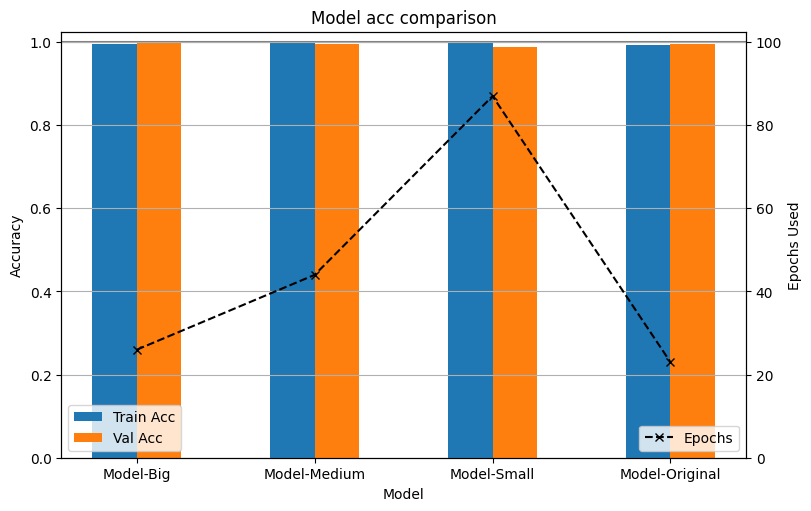

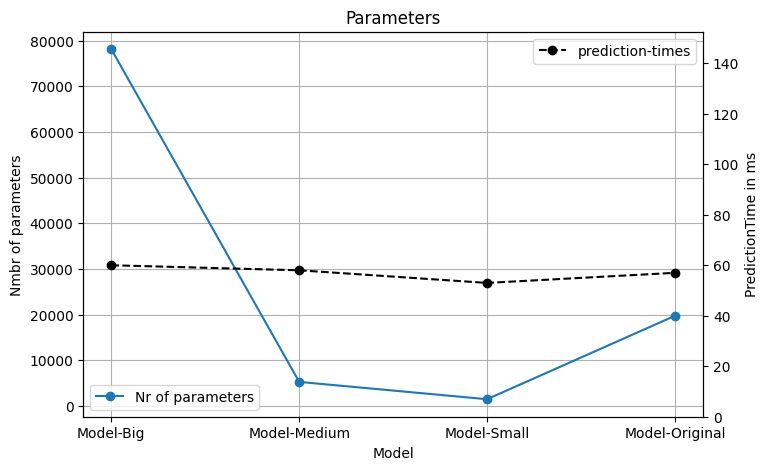

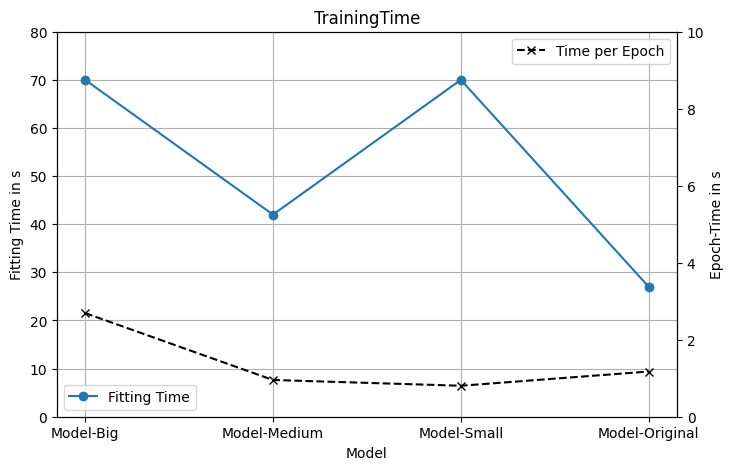

<Figure size 1500x700 with 0 Axes>

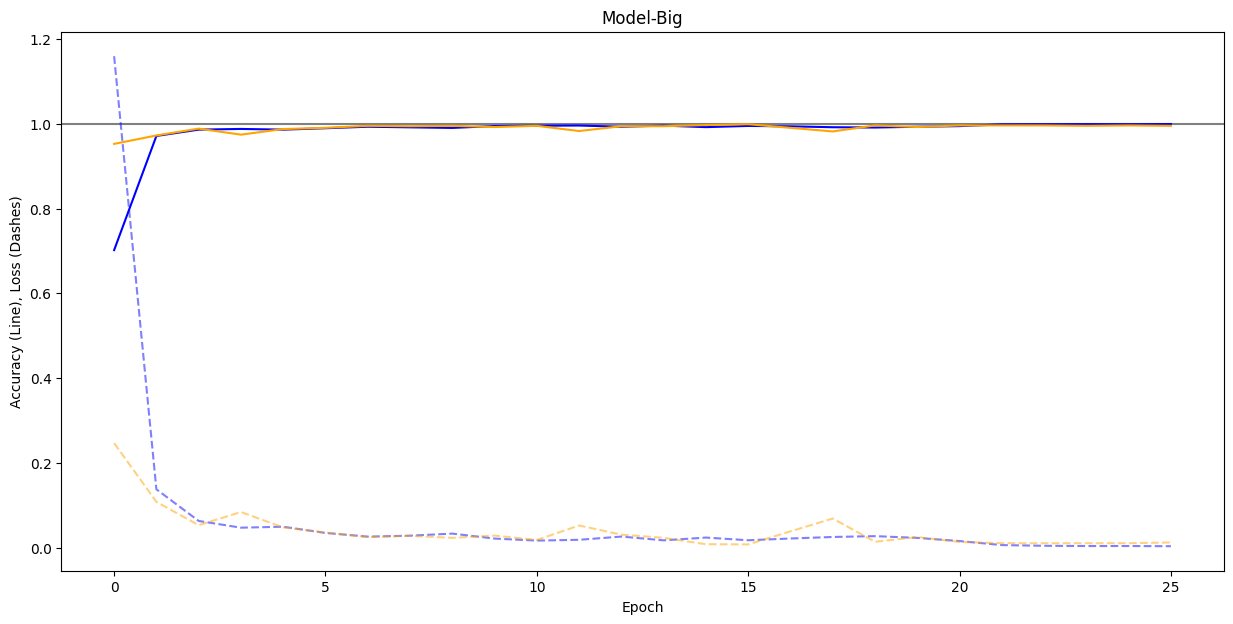

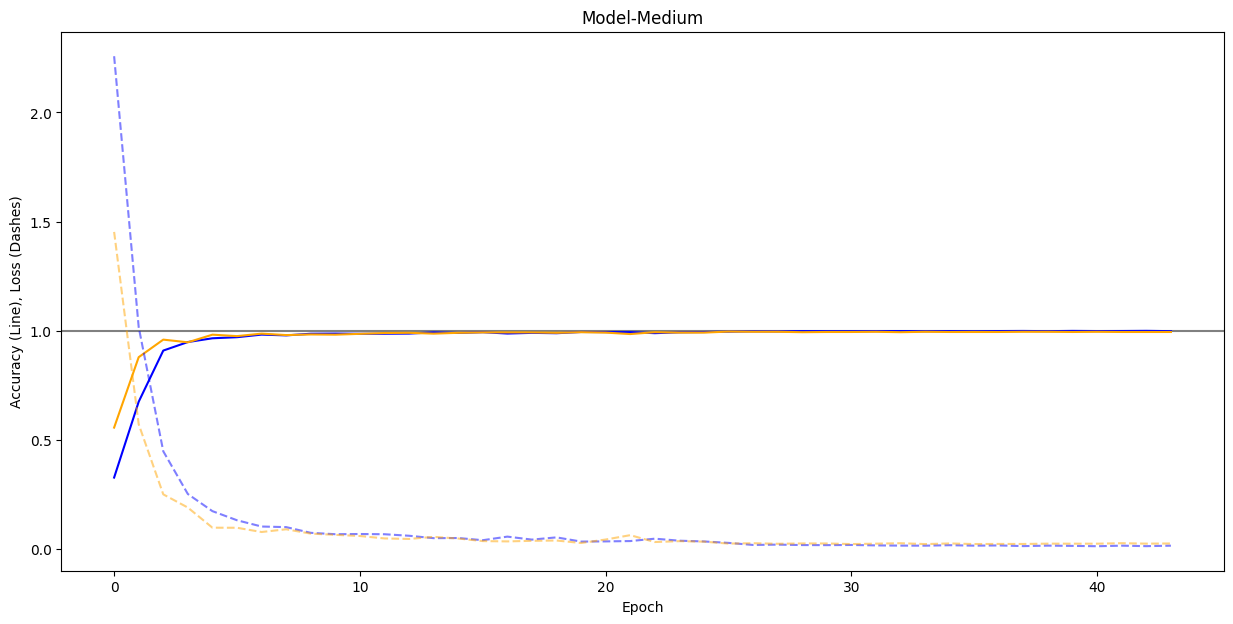

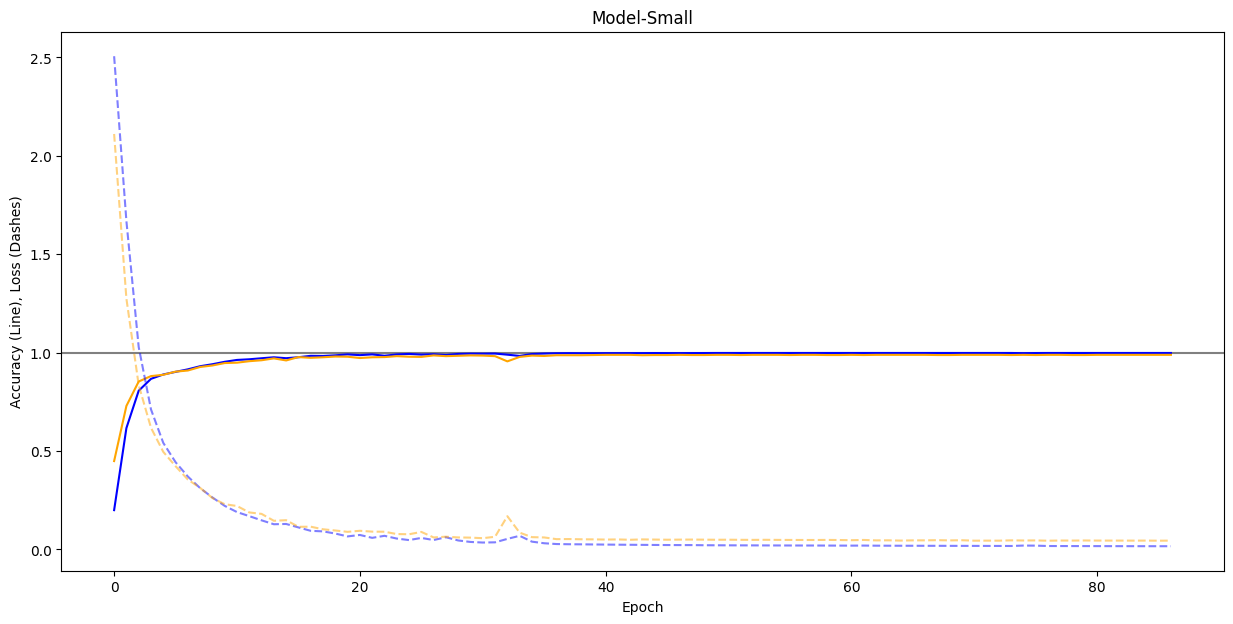

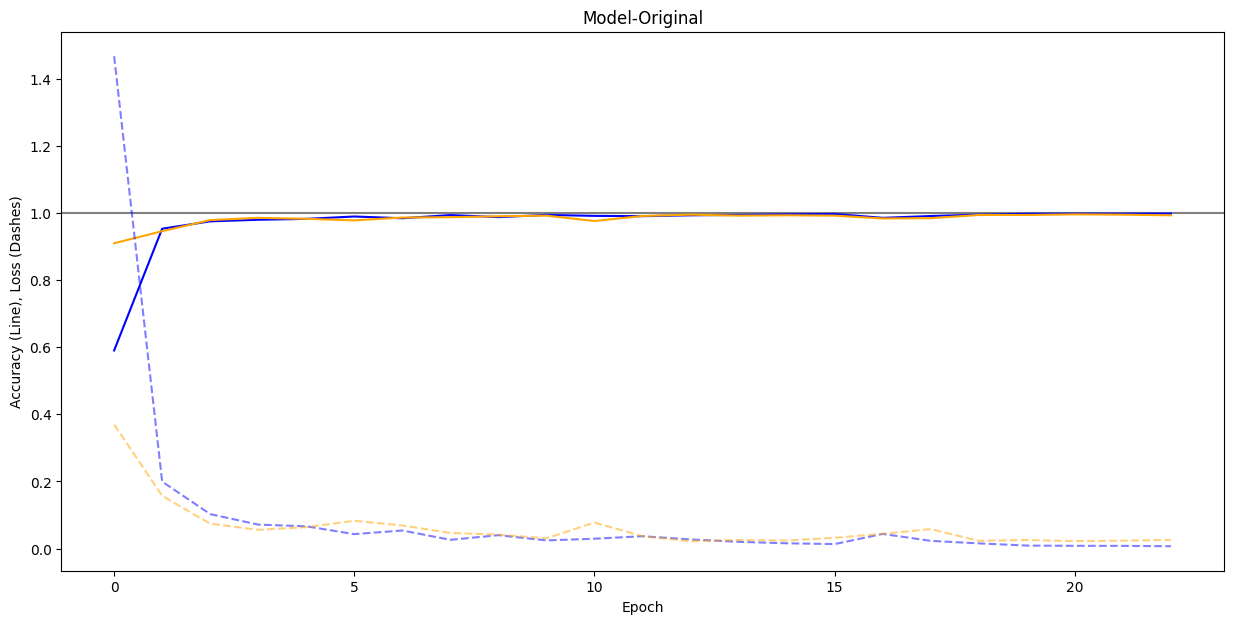

In [ ]:
import time

modelnames = []
parameterCounts = []
predtimes = []
val_accs = []
accs = []
epochs = []

for i, history in enumerate(histories):
    modelnames.append(models[i].name)
    num_params = models[i].count_params()

    _ = model.predict(my_X_test[:1], verbose=0) #seems like model needs longer on the first prediction so let it predict something before mesuring time
    
    startTime = int(time.time()*1000)
    predictionTimeTest = model.predict(X_test)
    #predictionTimeTest = model.predict(X_test[:1])

    duration = int(time.time()*1000) - startTime
    print(f"took {duration}ms to predict")
    predtimes.append(duration)
    parameterCounts.append(num_params)
    best_run = np.argmin(history.history['val_loss'])
    val_accs.append(history.history['val_accuracy'][best_run])
    accs.append(history.history['accuracy'][best_run])
    epochs.append(len(history.history['accuracy']))

    print(f"{models[i].name} Acc:{history.history['accuracy'][best_run]} ValAcc: {history.history['val_accuracy'][best_run]}")

fig, ax1 = plt.subplots(figsize=(8,5),constrained_layout=True)

x = np.arange(len(modelnames))  
width = 0.25                    

rects1 = ax1.bar(x - width/2, accs, width, label="Train Acc", color="tab:blue")
rects2 = ax1.bar(x + width/2, val_accs, width, label="Val Acc", color="tab:orange")

ax1.set_xticks(x)
ax1.set_xticklabels(modelnames)
ax1.set_xlabel("Model")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.025)
ax1.legend(loc="lower left")
ax1.axhline(1, color='gray')

ax2 = ax1.twinx()
ax2.plot(modelnames, epochs, marker="x", linestyle="--", color="black", label="Epochs")
ax2.set_ylabel("Epochs Used")
ax2.set_ylim(0,102.5)
ax2.legend(loc="lower right")

plt.xlabel("Models")
plt.title("Model acc comparison")
plt.grid(True)
plt.show()

#Pred time
fig1, axel = plt.subplots(figsize=(8,5))
axel.plot(modelnames, parameterCounts, marker="o", label="Nr of parameters")

axel.set_xlabel("Model")
axel.set_ylabel("Nmbr of parameters")
axel.set_title("Parameters")
axel.legend(loc="lower left")
axel.grid(True)

ax2 = axel.twinx()
ax2.plot(modelnames, predtimes, marker="o", linestyle="--", color="black", label="prediction-times")
ax2.set_ylabel("Prediction-Time in ms")
ax2.set_ylim(0,152.5)
ax2.legend(loc="upper right")

#Train time
fig1, axel = plt.subplots(figsize=(8,5))
axel.plot(modelnames, fittingTimes, marker="o", label="Fitting Time")

axel.set_xlabel("Model")
axel.set_ylabel("Fitting Time in s")
axel.set_title("TrainingTime")
axel.legend(loc="lower left")
axel.set_ylim(0,80)
axel.grid(True)

timesperEpoch = []
for i, hist in enumerate(histories):
    timePerStep = fittingTimes[i] / len(hist.history["loss"])
    timesperEpoch.append(timePerStep)                    

ax2 = axel.twinx()
ax2.plot(modelnames, timesperEpoch, marker="x", linestyle="--", color="black", label="Time per Epoch")
ax2.set_ylabel("Epoch-Time in s")
ax2.set_ylim(0,10)
ax2.legend(loc="upper right")

#HISTORY
plt.figure(figsize=(15, 7))
for i, history in enumerate(histories):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    
    fig = plt.figure(figsize=(15, 7))
    ax = plt.gca()
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (Line), Loss (Dashes)')
    
    ax.axhline(1, color='gray')

    plt.title(models[i].name)
    plt.plot(accuracy, color='blue')
    plt.plot(val_accuracy, color='orange')
    plt.plot(loss, '--', color='blue', alpha=0.5)
    plt.plot(val_loss, '--', color='orange', alpha=0.5)



## Predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
true label:   caret
prediction:   caret 0.99790263
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
true label:   caret
prediction:   caret 0.9994142
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
true label:   caret
prediction:   caret 0.99698085
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
true label:   caret
prediction:   caret 0.9954899


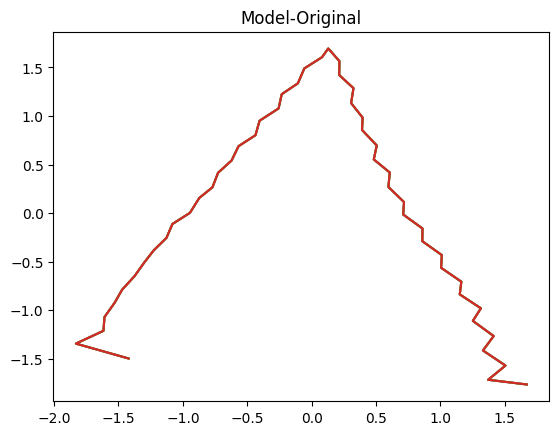

In [13]:
# lets test the model in action

# take random sample of test data and visualize
test_data = random.sample(myData, 1)[0]


label = test_data[0]
sequence = test_data[1]

# predict
for model in models:
    prediction = model.predict(np.array([sequence]))

    prediction_label_encoded = np.argmax(prediction)
    prediction_label = encoder.inverse_transform(np.array([prediction_label_encoded]))[0]
    plt.plot(sequence.T[0], sequence.T[1]*-1)
    plt.title(model.name)
    print('true label:  ', label)
    print('prediction:  ', prediction_label, prediction.max())

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


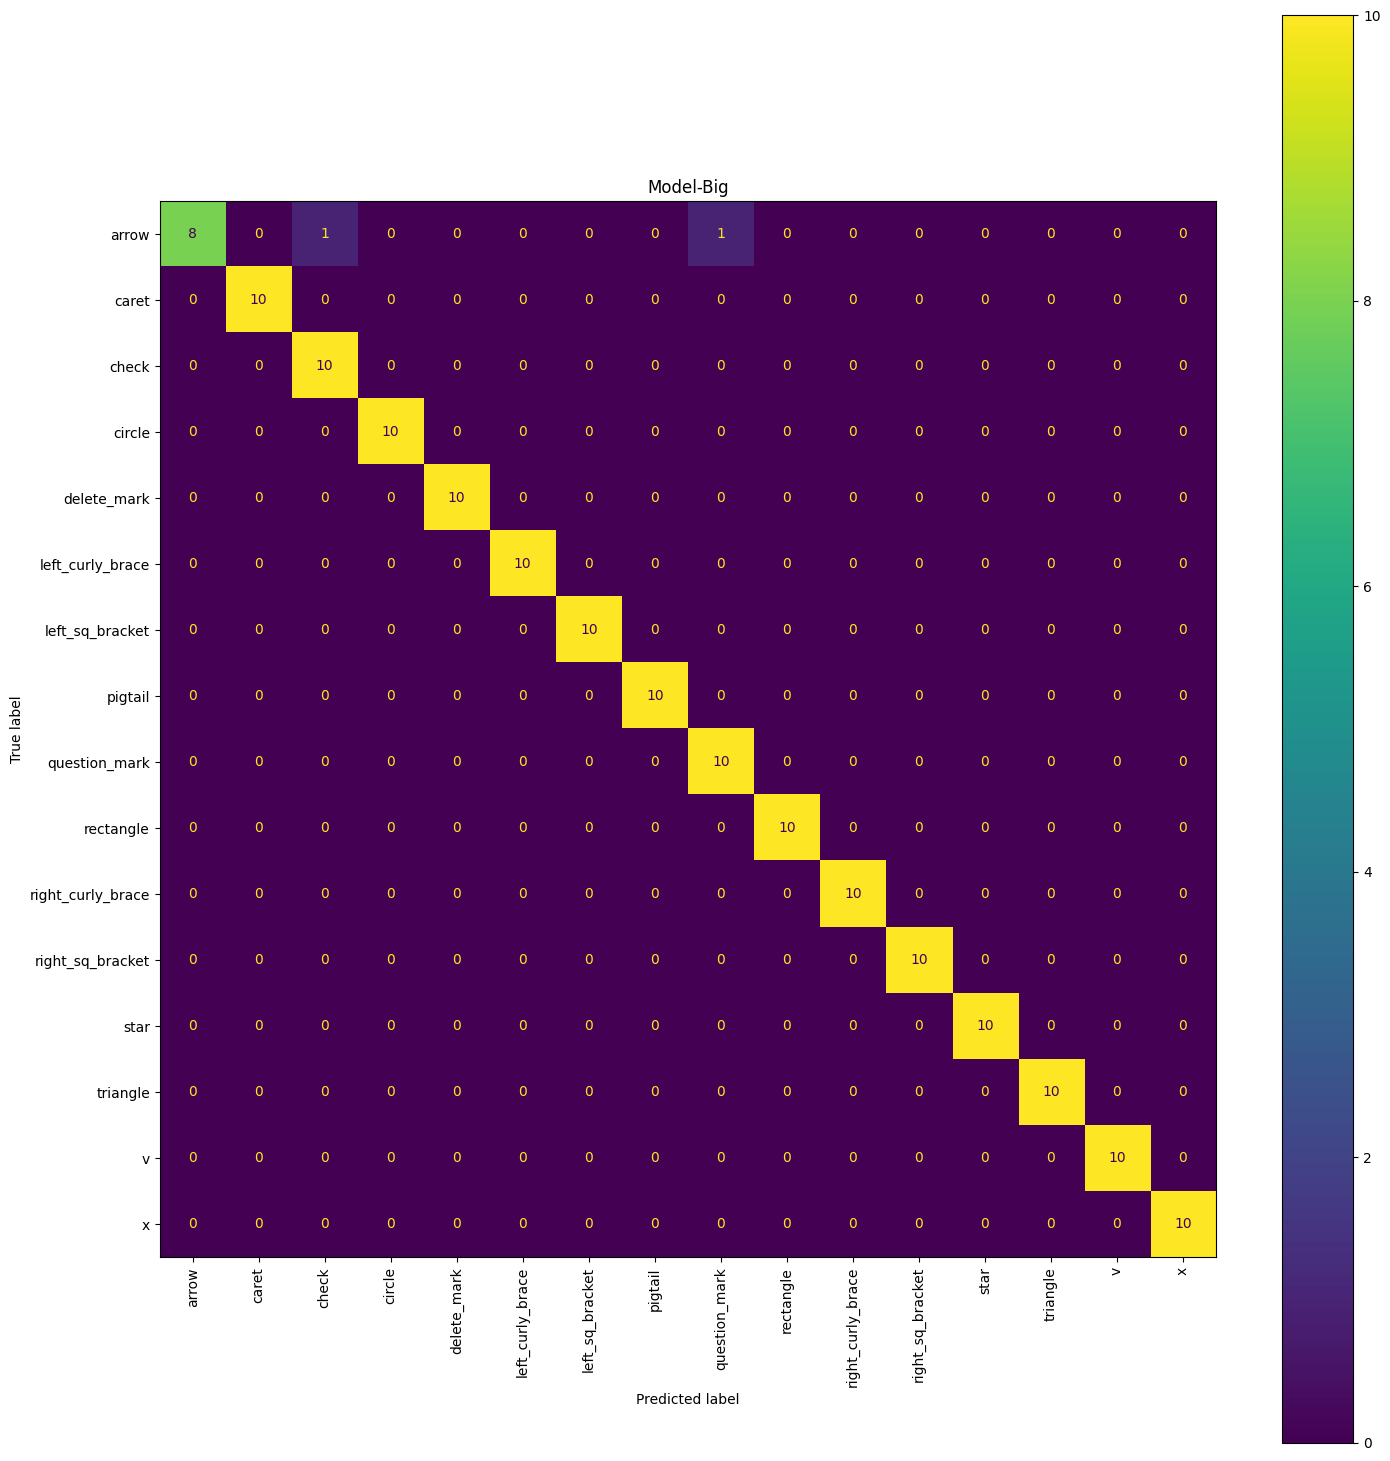

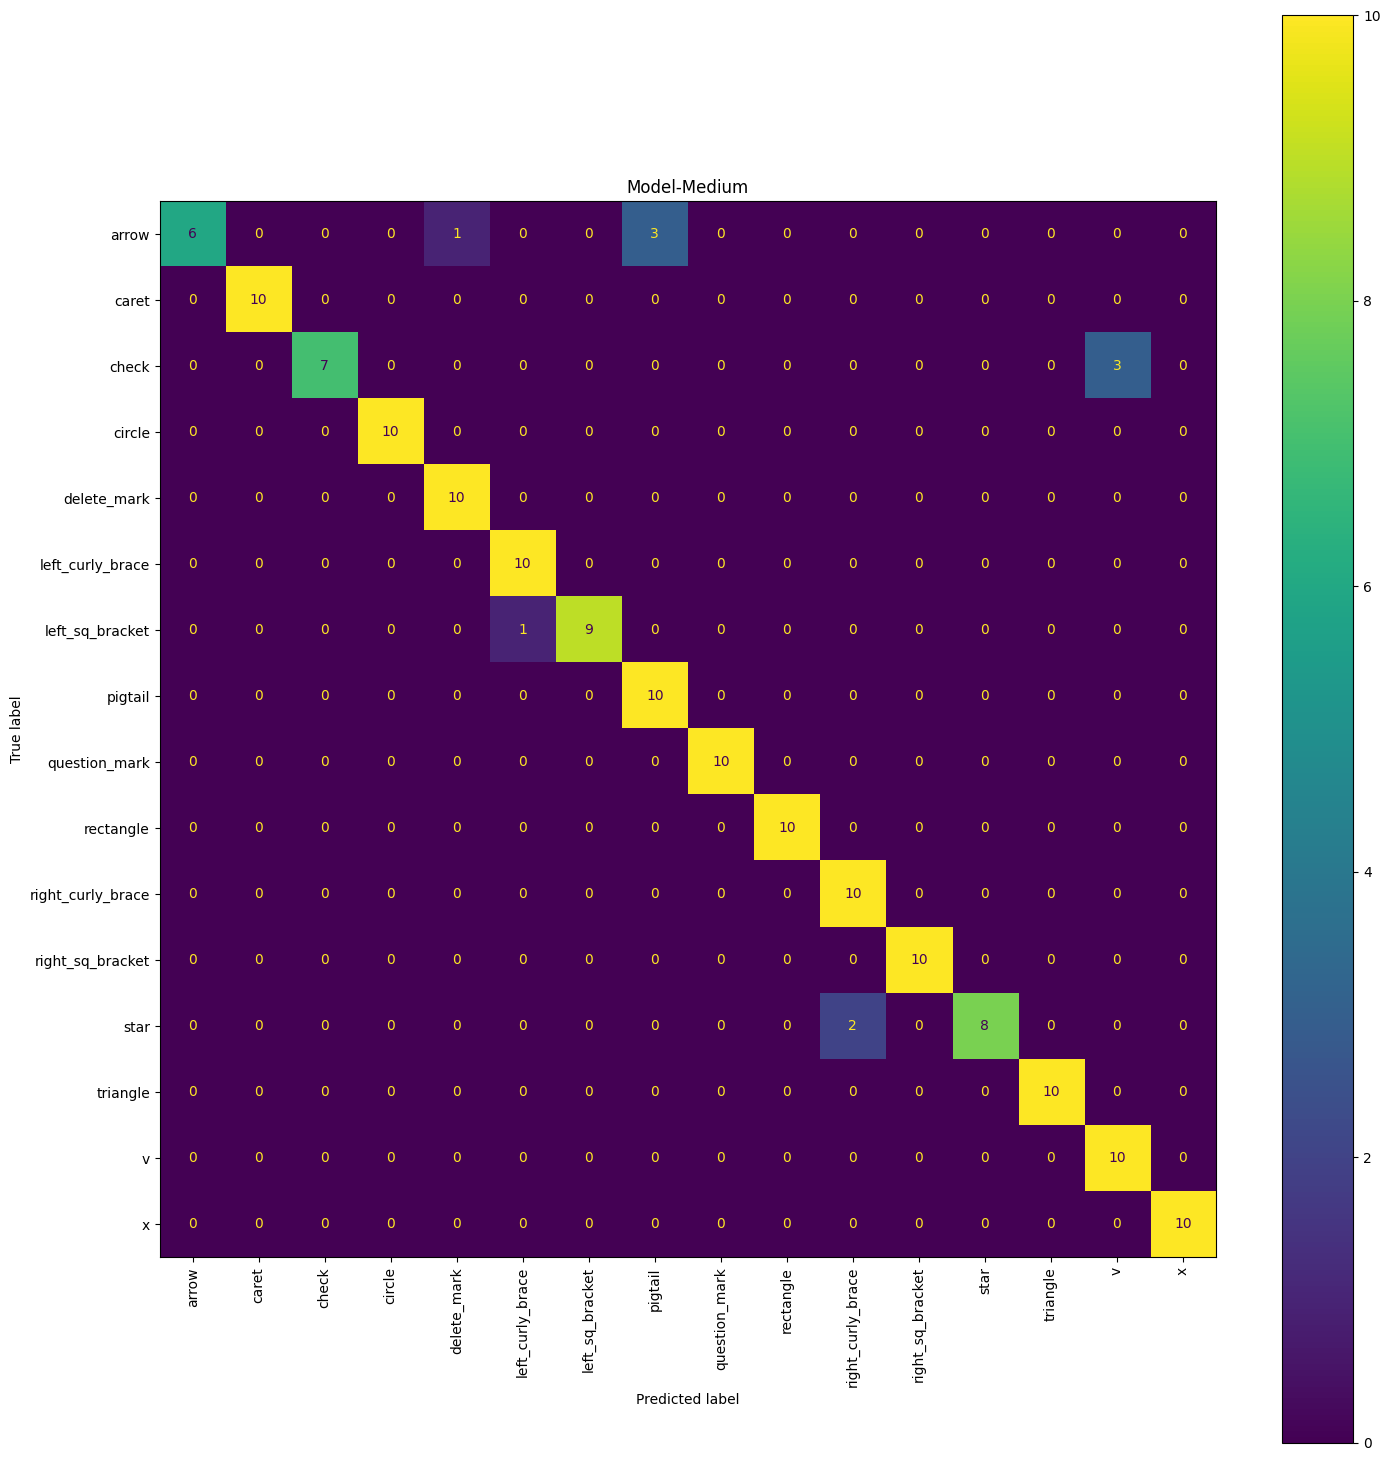

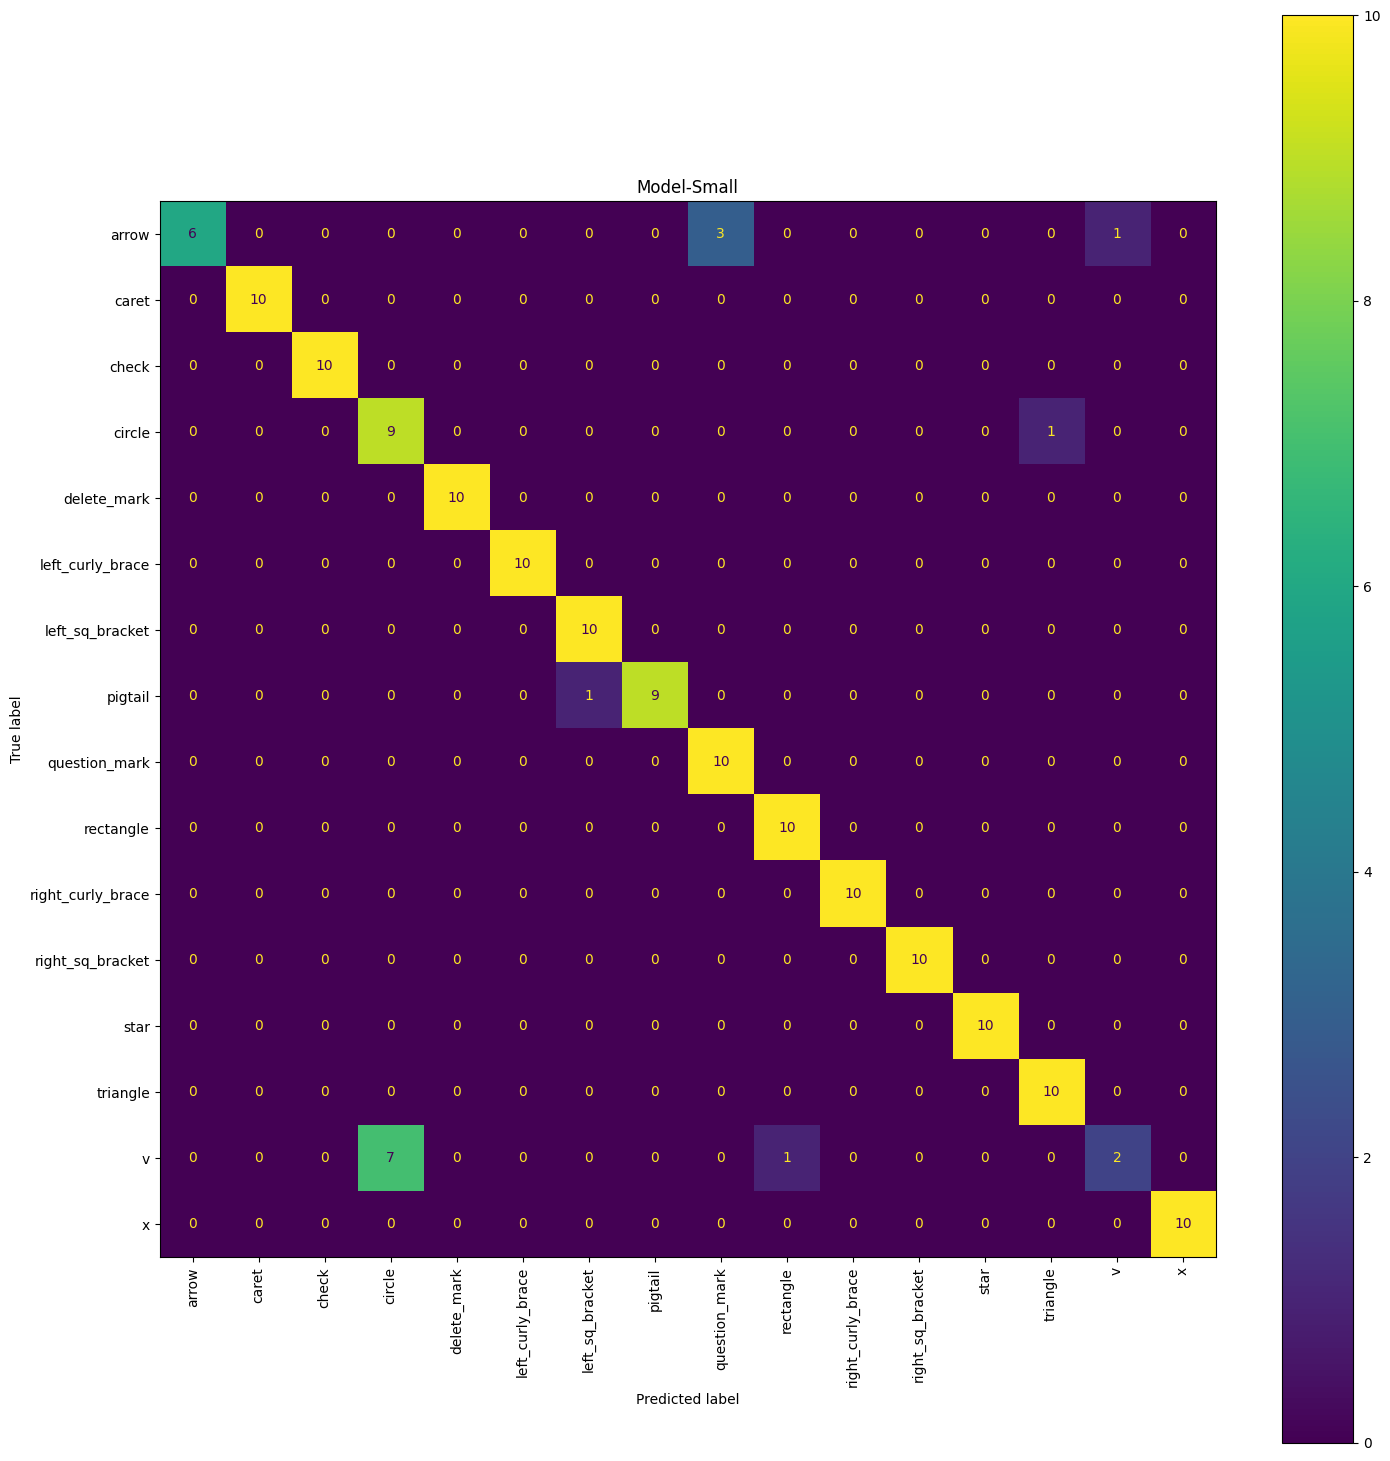

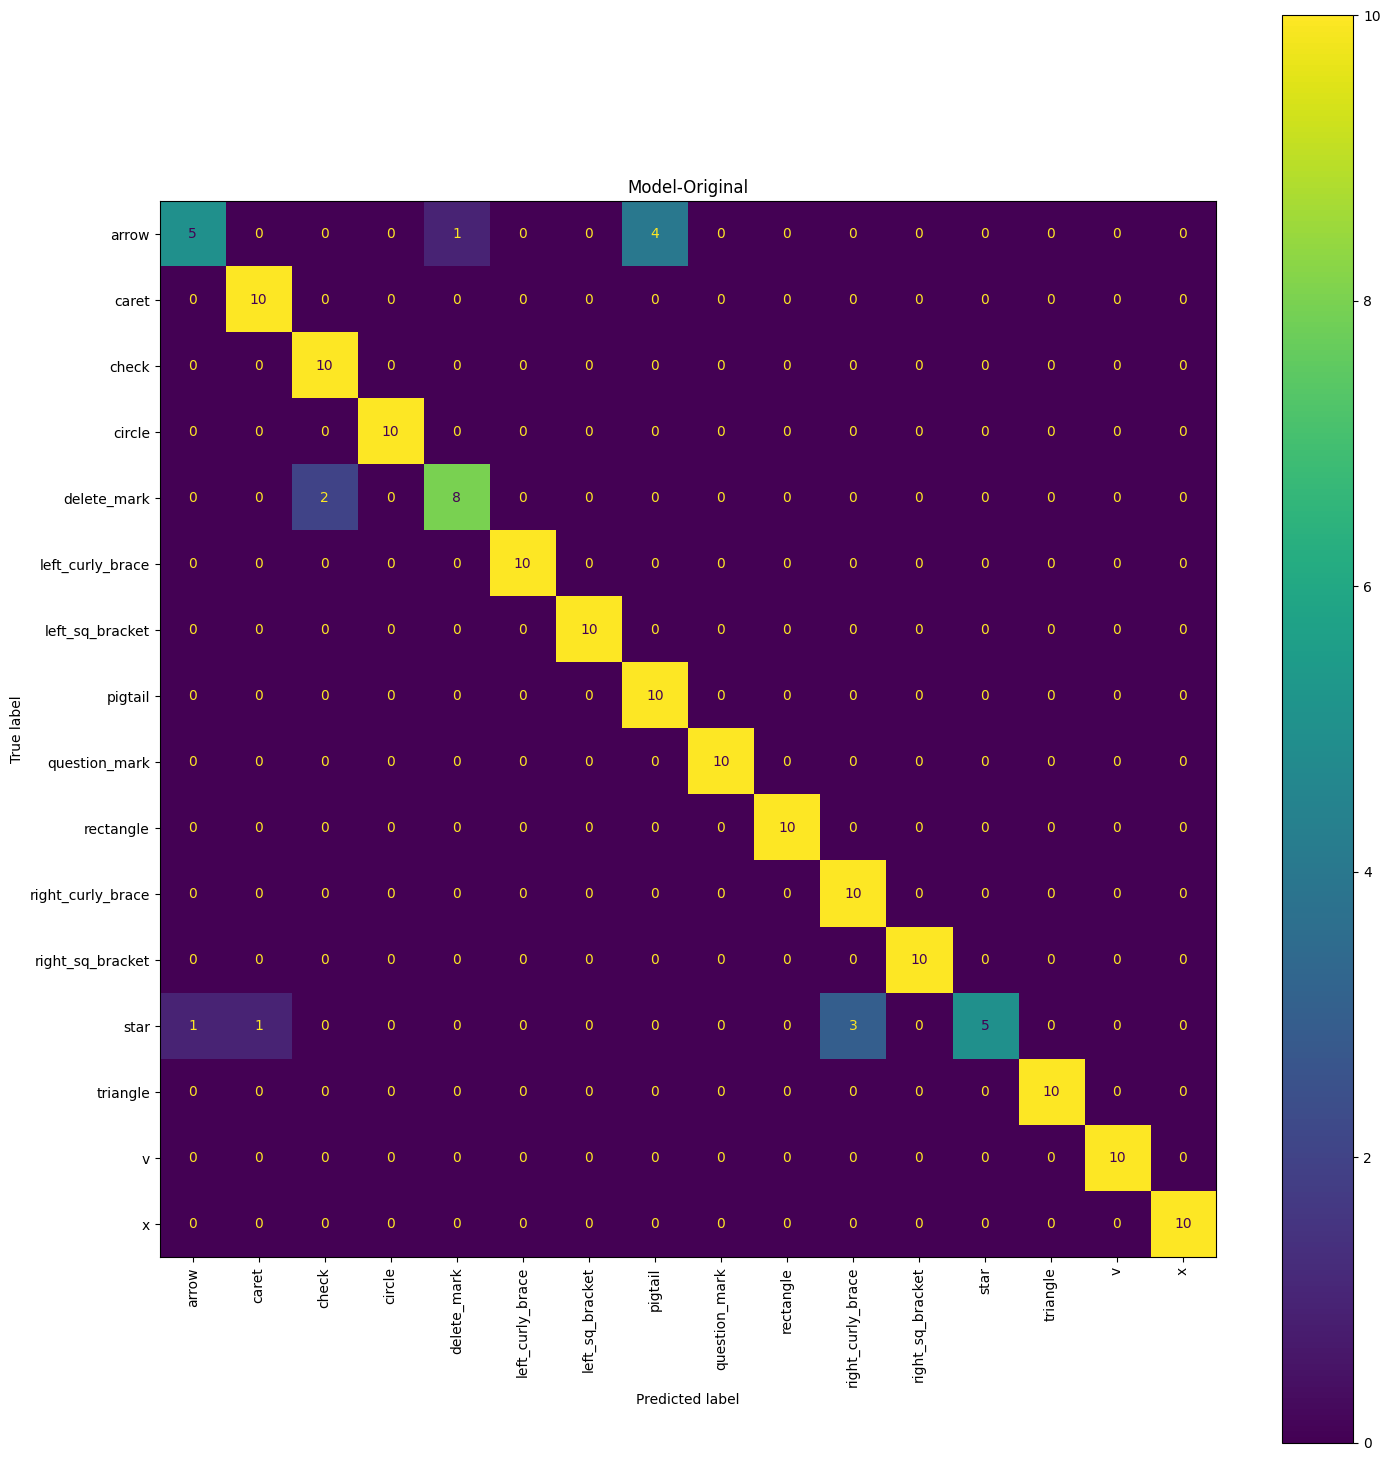

In [14]:
for model in models:
    my_prediction = model.predict(my_X_test)
    #print(my_prediction)
    my_predictions_arg = np.argmax(my_prediction, axis=1)
    y_test_arg = np.argmax(my_y_test, axis=1)
    
    conf_matrix = confusion_matrix(y_test_arg, my_predictions_arg)
    
    sortedlabels = sorted(list(set(myLabels)))
    
    fig, ax = plt.subplots(figsize=(15, 15))
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=sortedlabels)
    disp.plot(ax=ax, xticks_rotation=90)
    plt.title(model.name)
    plt.tight_layout()
    fig.savefig(f"confusion_matrix-{model.name}.png", bbox_inches='tight', dpi=300)

In [229]:
#fig.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)

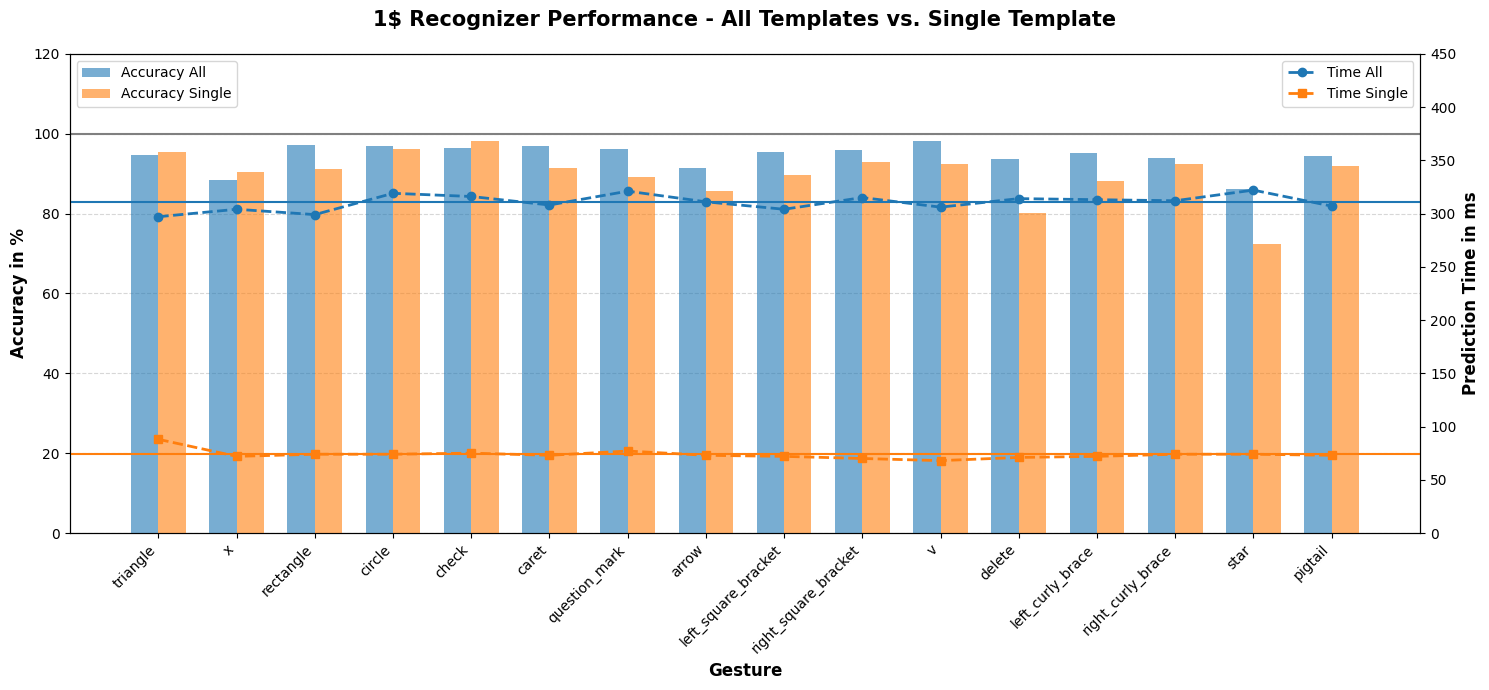

Mean Acc All:      94.4421%
Mean Time All:     310 ms
--------------------
Mean Acc Single:   89.8269%
Mean Time Single:  74 ms


In [37]:
# Gave Gemini the prediction-Data from the Task1 interface of the $1 Recognizer to put into lists
data_all = [
    ("triangle", 0.9475763356228704, 297), ("x", 0.88399777194827, 304),
    ("rectangle", 0.972835659349501, 299), ("circle", 0.968169485159314, 319),
    ("check", 0.9643917338600569, 316), ("caret", 0.969520928117188, 308),
    ("question_mark", 0.9620882269504666, 321), ("arrow", 0.9148908967282428, 311),
    ("left_square_bracket", 0.9549403314387027, 304), ("right_square_bracket", 0.9591740469025932, 315),
    ("v", 0.9811528419429367, 306), ("delete", 0.9369828890177925, 314),
    ("left_curly_brace", 0.952611096914536, 313), ("right_curly_brace", 0.9393412879516897, 312),
    ("star", 0.8602243144765311, 322), ("pigtail", 0.9428343251229788, 307)
]

data_single = [
    ("triangle", 0.9529010748669267, 88), ("x", 0.9051228507243941, 72),
    ("rectangle", 0.9112448720241941, 74), ("circle", 0.9604392070624349, 74),
    ("check", 0.9824102837008803, 75), ("caret", 0.9136293287784322, 73),
    ("question_mark", 0.8902574082734495, 77), ("arrow", 0.855409008033559, 73),
    ("left_square_bracket", 0.8974738355856667, 72), ("right_square_bracket", 0.9295730226483143, 70),
    ("v", 0.9230828762428986, 68), ("delete", 0.8025272678894672, 71),
    ("left_curly_brace", 0.88133935988084, 72), ("right_curly_brace", 0.9236788965565057, 74),
    ("star", 0.7249475604041156, 74), ("pigtail", 0.9182678168793104, 73)
]

labels = [item[0] for item in data_all]
x = np.arange(len(labels))
width = 0.35

acc_all = [item[1] * 100 for item in data_all]
times_all = [item[2] for item in data_all]

acc_single = [item[1] * 100 for item in data_single]
times_single = [item[2] for item in data_single]

fig, ax1 = plt.subplots(figsize=(15, 7))
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

bar1 = ax1.bar(x - width/2, acc_all, width, label='Accuracy All', color='#1f77b4', alpha=0.6, zorder=3)
bar2 = ax1.bar(x + width/2, acc_single, width, label='Accuracy Single', color='#ff7f0e', alpha=0.6, zorder=3)

ax1.set_xlabel('Gesture', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy in %', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 120)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left')
ax1.axhline(100, color='gray')

ax2 = ax1.twinx()
line1 = ax2.plot(x, times_all, color='#1f77b4', marker='o', linewidth=2, linestyle='--', label='Time All', zorder=4)
line2 = ax2.plot(x, times_single, color='#ff7f0e', marker='s', linewidth=2, linestyle='--', label='Time Single', zorder=4)
ax2.legend(loc='upper right')
ax2.set_ylabel('Prediction Time in ms', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 450)
meanAll = np.mean(times_all)
meanSingle = np.mean(times_single)

ax2.axhline(meanAll, color='#1f77b4')
ax2.axhline(meanSingle, color='#ff7f0e')


plt.title('1$ Recognizer Performance - All Templates vs. Single Template', fontsize=15, fontweight='bold', pad=20)
fig.tight_layout()


plt.show()

meanAccAll = np.mean(acc_all)
meanAccSingle = np.mean(acc_single)
print(f"Mean Acc All:      {meanAccAll:.4f}%")
print(f"Mean Time All:     {meanAll:.0f} ms")
print("--------------------")
print(f"Mean Acc Single:   {meanAccSingle:.4f}%")
print(f"Mean Time Single:  {meanSingle:.0f} ms")

# Result

## Method
For the $1-recognizer I used the code from Task 1 to predict gestures in the Application, used the single thread to get the time it took and saved accuracy and time into data-all and data-single, which can be seen above. Data-Single uses one template per gesture, data-all useses ten templates per gesture.   
For the LSTM I trained the model on the Log-Data of Wobbrock with a 80/20 train-test-split. I trained 4 models simultaniously: 3 with decreasing number of parameters and 1 unchanged model (from the lesson). For Testing/predictions I used my own collected data which wasn't included in the training or testing-data.


## Obserservations and Discussion
| Model | Trainable Parameters | Epochs | Train Acc | Val Acc | inverenceTime (one element) | inverenceTime (whole test data)
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Big-Model** | 78,128 | 28 | 0.9950 | 0.9990 | 60ms | 223ms
| **Medium-Model** | 5,280 | 27 | 0.9969 | 0.9943 | 58ms | 215ms
| **Small-Model** | 1,488 | 97 | 0.9981 | 0.9886 | 53ms | 212ms
| **Original-Model** | 19,760 | 36 | 0.9934 | 0.9953 | 57ms | 213ms
| **1$ recognizer** | ??? | ??? | ??? | 0.90 - 0.94  | ~75ms | ~310ms

<br>  

> **Disclaimer**:   
For the $1-Recognizer inverence time references using one template per gesture/all templates per gesture  
The tests were done with data not included in train-test-split of training data!

Firstly, when giving each model enough time the accuracy got really good (couldn't reproduce it, but at one point all conf-matrices had 100% accuracy). When left on 10 or 20 epochs the small model was MUCH worse, maxing out val-acc at 0.80. This can also be seen in the fitting, the Big-Model reached acc above 0.9 with the second epoch, the others took a little bit longer.
As can be seen the Parameters get reduced drastically with number of layers. It’s also notable that the small model took at one point lot of epochs (98) to train but continued improving through all of it.
The prediction-time has negligent small differences with the big-model taking ever so slightly longer on the whole test-data (other runs had pred-time at ~75ms, the last one at ~57ms).
Fitting time is generally longer for more parameters, but it's pretty random, e.g. in the last run small and big model had the same fitting time.
The discrepancys for arrow in the conf-matrix of big-model can be explained since i varied my own arrows between straight and curved, which wasn't in the pre-existing log_data. I also deliberatly made some checks very similar to vs. For why v got predicted as circle in the small-model i really have no clue, maybe because the path of the y coordinate is being very similar.


So to summarize the LSTM-Models:
The difference between the models is suprisingly small, the biggest outlier is the number of epochs for the small-model, so if I had to decide what to use I would propably opt for the Big Model, beacause the high accuracy and pretty similar prediction-times. In previous iterations all 3 Models hat a perfect confusion matrix, but even in that case I'd opt for the big model just to be sure.

The comparison of the $1 recoginizer is really interisting, the way i loaded the templates is to just use the templates i recorded for the testing in this notebook. For performance reasons i just checked the first of each template, which lead to the result that arrows constantly got recognized as pigtails? I checked which templates were the most accurate and got:

arrow02.xml  
('arrow', 0.9537561668080238) Took time: 308ms  
arrow05.xml  
('arrow', 0.8741188086036289) Took time: 308ms  
arrow09.xml  
('arrow', 0.8972166262511805) Took time: 306ms  

never arrow01, something simillar happend with bracket and check, so to really get a more general prediction more templates should be used for recognition or in painstaking manual labor figuring out the best template...which i did partly. I was also really suprised no wrong prediction occoured when collecting data for the above plot.
The code with only one template per gesture took around **74ms** for prediction, which could propably be improved my caching templates in code and not copying the array to flip vertically beacause of pyglet. But the speed increase should be minimal. When using all templates it took around **311ms** (so 4times as long for 10times more templates), but was more accurate.
In the Attachment bellow one can see how different templates were used for prediction. With some work one could isolate the best templates and optimize accuracy and perdictiontime, but would be pretty time-consuming.
I also predicted my testdata with the whole xml_logs, which took **10sec** per prediction and as a whole **27min** and got a accuracy of **0.97** which is only marginally better than using my templated for prediction.

In comparison to the LSTM-Model the time per prediction (single element) is pretty similar to the LSTM, but it's more accurate and generalised. The code for the \\$1 recogniser is also much more complicated than the Neural-Network (to be fair just because some genius people behind keras/tensorflow really made it easy to use!). The comparison of prediction times in the table above isn't really great, since for $1 it's always one element, for the model it were 160, so really the 310ms should also be compared to the ~60ms of the model.
(It's noteable that previous iterations had the predTime of model at ~75 and ~260ms, which is closer to $1-Recognizer)

Overall I think i prefer the LSTM-Model, simply because it's easier to implement and i can imagine it's more generalised as the confusion-matrices show. Also with more similar gestures the $1 could pretty quickly reach it's limit.


In [ ]:
# Attachments:

## $1 recognizer accuracies:

### One template per gesture:
left_sq_bracket01.xml
('left_square_bracket', 0.8999704232844236) Took time: 69ms
caret01.xml
('caret', 0.9237164505833315) Took time: 72ms
circle01.xml
('circle', 0.9148166887558088) Took time: 73ms
rectangle01.xml
('rectangle', 0.9397314857659763) Took time: 72ms
arrow01.xml
('arrow', 0.8773421647474948) Took time: 74ms
right_sq_bracket01.xml
('right_square_bracket', 0.9187040865811062) Took time: 82ms
left_sq_bracket01.xml
('left_square_bracket', 0.9394457577025472) Took time: 73ms
left_curly_brace01.xml
('left_curly_brace', 0.8439852767984233) Took time: 73ms
right_curly_brace01.xml
('right_curly_brace', 0.9298217502837575) Took time: 74ms

### All Templates:
left_sq_bracket02.xml
('left_square_bracket', 0.9459094330132121) Took time: 341ms
caret03.xml
('caret', 0.964737795953267) Took time: 299ms
circle05.xml
('circle', 0.9644655117088012) Took time: 313ms
rectangle08.xml
('rectangle', 0.960867984678381) Took time: 326ms
arrow09.xml
('arrow', 0.9045014408818) Took time: 311ms
right_sq_bracket07.xml
('right_square_bracket', 0.9726567104994125) Took time: 293ms
left_sq_bracket02.xml
('left_square_bracket', 0.9411275625218135) Took time: 304ms
left_curly_brace10.xml
('left_curly_brace', 0.9123238277886075) Took time: 316ms
right_curly_brace08.xml
('right_curly_brace', 0.9319474364792991) Took time: 309ms


SyntaxError: invalid decimal literal (3302674621.py, line 7)